# Teach RNN Motion

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# System imports
from pathlib import Path
import sys
from datetime import date
from collections import defaultdict
import json

# Plotting imports
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# Scientific imports
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from scipy.stats import zscore, spearmanr
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

# NN imports
import torch
import neurogym as ngym

# For import from src folder in linux
ROOT = Path().cwd().parent
SRC_PATH = ROOT / 'src'
sys.path.append(str(ROOT))
sys.path.append(str(SRC_PATH))

# Custom imports
from src.environments import TAMTask, MotionTask, load_motion_from_image, load_tam_from_image
from src.train_test_utils import plot_dataset, plot_training_curves
from src.networks import TAMNet
from src.utils import load_params

In [172]:
# Plotting settings
custom_palette = sns.color_palette(["#E74C3C", "#2ECC71"]) # a custom palette with red and green
custom_params = {
    "axes.spines.right": False,
    "axes.spines.top": False
}
sns.set_theme(
    font_scale=1,
    style='white',
    context='poster',
    font='Franklin Gothic Book',
    rc=custom_params
)

## 0. Basic settings


In [3]:
%matplotlib inline

In [4]:
# Set directories
# Figures
today = date.today().strftime('%m-%d-%Y')
FIG_DIR = ROOT / 'figures' / today
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Network
MODEL_DIR = ROOT / 'data' / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Stimuli
STIM_DIR = ROOT / 'data' / 'stimuli' / "TAM_basic"

In [5]:
# Load parameters
params = load_params(str(ROOT / 'parameters.json'))
exp_params = params["EXPERIMENT"]
env_params = params['TASK']
training_envs = defaultdict()
training_datasets = defaultdict()
motion_dirs = ["horizontal"]
box_shapes = ["square", "circle", "triangle"]

img_size = 32
batch_size = 128
seq_len = 10

In [7]:
# WORKED
# img_size = 64
# batch_size = 16
# seq_len = 100

# Higher batch size generalizes to other shapes
# Higher seq_len generalizes to outlines

In [52]:
# Create environments and datasets
for md in motion_dirs:
    for bs in box_shapes:
        print(md, bs)
        stimuli = load_tam_from_image(img_size, stim_path=STIM_DIR)
        env = TAMTask(
            box_shape=bs,
            stim_type="tam",
            stimuli=stimuli,
            stim_ori=md,
            dt=env_params["dt"],
            # sigma=env_params["sigma"],
            sigma=0,
            img_size=img_size
        )
        env.reset(no_step=True)

        # Generate dataset object
        dataset = ngym.Dataset(
            env,
            batch_size=batch_size,
            seq_len=seq_len
        )

        # Add dataset to dictionary
        training_envs[f'{bs}-{md}'] = env
        training_datasets[f'{bs}-{md}'] = dataset

horizontal square
horizontal circle
horizontal triangle


In [53]:
# Create environments and datasets
tam_test_datasets = defaultdict()
motion_test_datasets = defaultdict()
tam_types = ["tam", "outline"]
motion_types = ["cnt", "track"]

for bs in box_shapes:
    for tt in tam_types:
        for md in motion_dirs:
            print(bs, tt, md)
            if tt == "tam":
                _path = STIM_DIR
            else:
                _path = STIM_DIR.parent / "TAM_outline"

            stimuli = load_tam_from_image(img_size, stim_type=tt, stim_path=_path)
            env = TAMTask(
                box_shape=bs,
                stimuli=stimuli,
                stim_type=tt,
                stim_ori=md,
                dt=env_params["dt"],
                sigma=0.01,
                img_size=img_size
            )
            env.reset(no_step=True)

            # Generate dataset object
            dataset = ngym.Dataset(
                env,
                batch_size=batch_size,
                seq_len=seq_len
            )

            # Add dataset to dictionary
            tam_test_datasets[f'{bs}-{tt}-{md}'] = env
            tam_test_datasets[f'{bs}-{tt}-{md}'] = dataset

# for bs in box_shapes:
#     for mt in motion_types:
#         for md in motion_dirs:
#
#             print(bs, mt, md)
#
#             stimuli = load_motion_from_image(img_size, stim_path=STIM_DIR.parent / "motion_task")
#             env = MotionTask(
#                 dt=env_params["dt"],
#                 box_shape=bs,
#                 motion_type=mt,
#                 stim_ori=md,
#                 stimuli=stimuli,
#                 sigma=0,
#                 img_size=img_size
#             )
#             env.reset(no_step=True)
#
#             # Generate dataset object
#             dataset = ngym.Dataset(
#                 env,
#                 batch_size=batch_size,
#                 seq_len=seq_len
#             )
#
#             # Add dataset to dictionary
#             motion_test_datasets[f'{bs}-{mt}-{md}'] = env
#             motion_test_datasets[f'{bs}-{mt}-{md}'] = dataset

square tam horizontal
square outline horizontal
circle tam horizontal
circle outline horizontal
triangle tam horizontal
triangle outline horizontal


In [54]:
# Look at the shapes of the datasets
inputs, target = training_datasets["square-horizontal"]()
print('Input has shape (SeqLen, Batch, C, W, H) =', inputs.shape)
print('Target has shape (SeqLen, Batch) =', target.shape)
print('Targets in the first sequence:')
print(target[:, 0])

Input has shape (SeqLen, Batch, C, W, H) = (10, 128, 32, 32)
Target has shape (SeqLen, Batch) = (10, 128)
Targets in the first sequence:
[0 0 0 0 0 0 0 0 0 3]


In [336]:
# Load parameters
net_params = params['NETWORK']
device = torch.device(net_params["device"])
# device = torch.device('cpu')

# Create network to train on the normal stimuli
net = TAMNet(
    dataset=training_datasets["square-horizontal"],
    hidden_size=256,
    output_size=training_datasets["square-horizontal"].env.action_space.n,
    learning_rate=0.001,
    device=device
)

In [337]:
# Train network
train_loss, train_acc = net.train_rnn(
    datasets=[
        training_datasets["square-horizontal"],
        # training_datasets["triangle-horizontal"],
        # training_datasets["circle-horizontal"],
    ],
    # n_epochs=net_params["n_epochs"]
    n_epochs=200
)

Training started...
Step 100, Loss 0.2829, Time 6.3s
Step 200, Loss 0.0231, Time 12.6s


In [393]:
trained_rnn = net.RNN

In [394]:
# save network
torch.save(trained_rnn.state_dict(), MODEL_DIR / f'learned_horiz_TAM-basic_256_VSS_only_last.pt')

In [339]:
net.RNN.eval()

RNNNet(
  (rnn): CTRNN(
    (input2h): Linear(in_features=1024, out_features=128, bias=True)
    (h2h): Linear(in_features=128, out_features=128, bias=True)
  )
  (fc): Linear(in_features=128, out_features=6, bias=True)
)

In [161]:
net.RNN.fc.weight.shape

RNNNet(
  (rnn): CTRNN(
    (input2h): Linear(in_features=1024, out_features=256, bias=True)
    (h2h): Linear(in_features=256, out_features=256, bias=True)
  )
  (fc): Linear(in_features=256, out_features=6, bias=True)
)

In [340]:
net = TAMNet(
    dataset=training_datasets["square-horizontal"],
    hidden_size=256,
    output_size=training_datasets["square-horizontal"].env.action_space.n,
    learning_rate=0.001,
    device=device
)

# Load the trained weights
model = net.RNN
model.load_state_dict(torch.load(MODEL_DIR / 'learned_horiz_TAM-basic_256_VSS_only_last.pt'))
model.eval()

Accuracy on square-tam-horizontal = 1.0
Accuracy on square-outline-horizontal = 1.0
Accuracy on circle-tam-horizontal = 0.742
Accuracy on circle-outline-horizontal = 0.726
Accuracy on triangle-tam-horizontal = 0.884
Accuracy on triangle-outline-horizontal = 0.546


In [59]:
# Test on other environments
test_accuracies = defaultdict()
test_activities = defaultdict()
infos = defaultdict()
for et, dataset in tam_test_datasets.items():
    info, activity, test_acc = net.test_rnn(500, dataset)
    infos[et] = info
    test_accuracies[et] = test_acc
    test_activities[et] = activity
    print(f'Accuracy on {et} = {test_acc}')

Accuracy on square-tam-horizontal = 1.0
Accuracy on square-outline-horizontal = 1.0
Accuracy on circle-tam-horizontal = 0.73
Accuracy on circle-outline-horizontal = 0.466
Accuracy on triangle-tam-horizontal = 0.878
Accuracy on triangle-outline-horizontal = 0.322


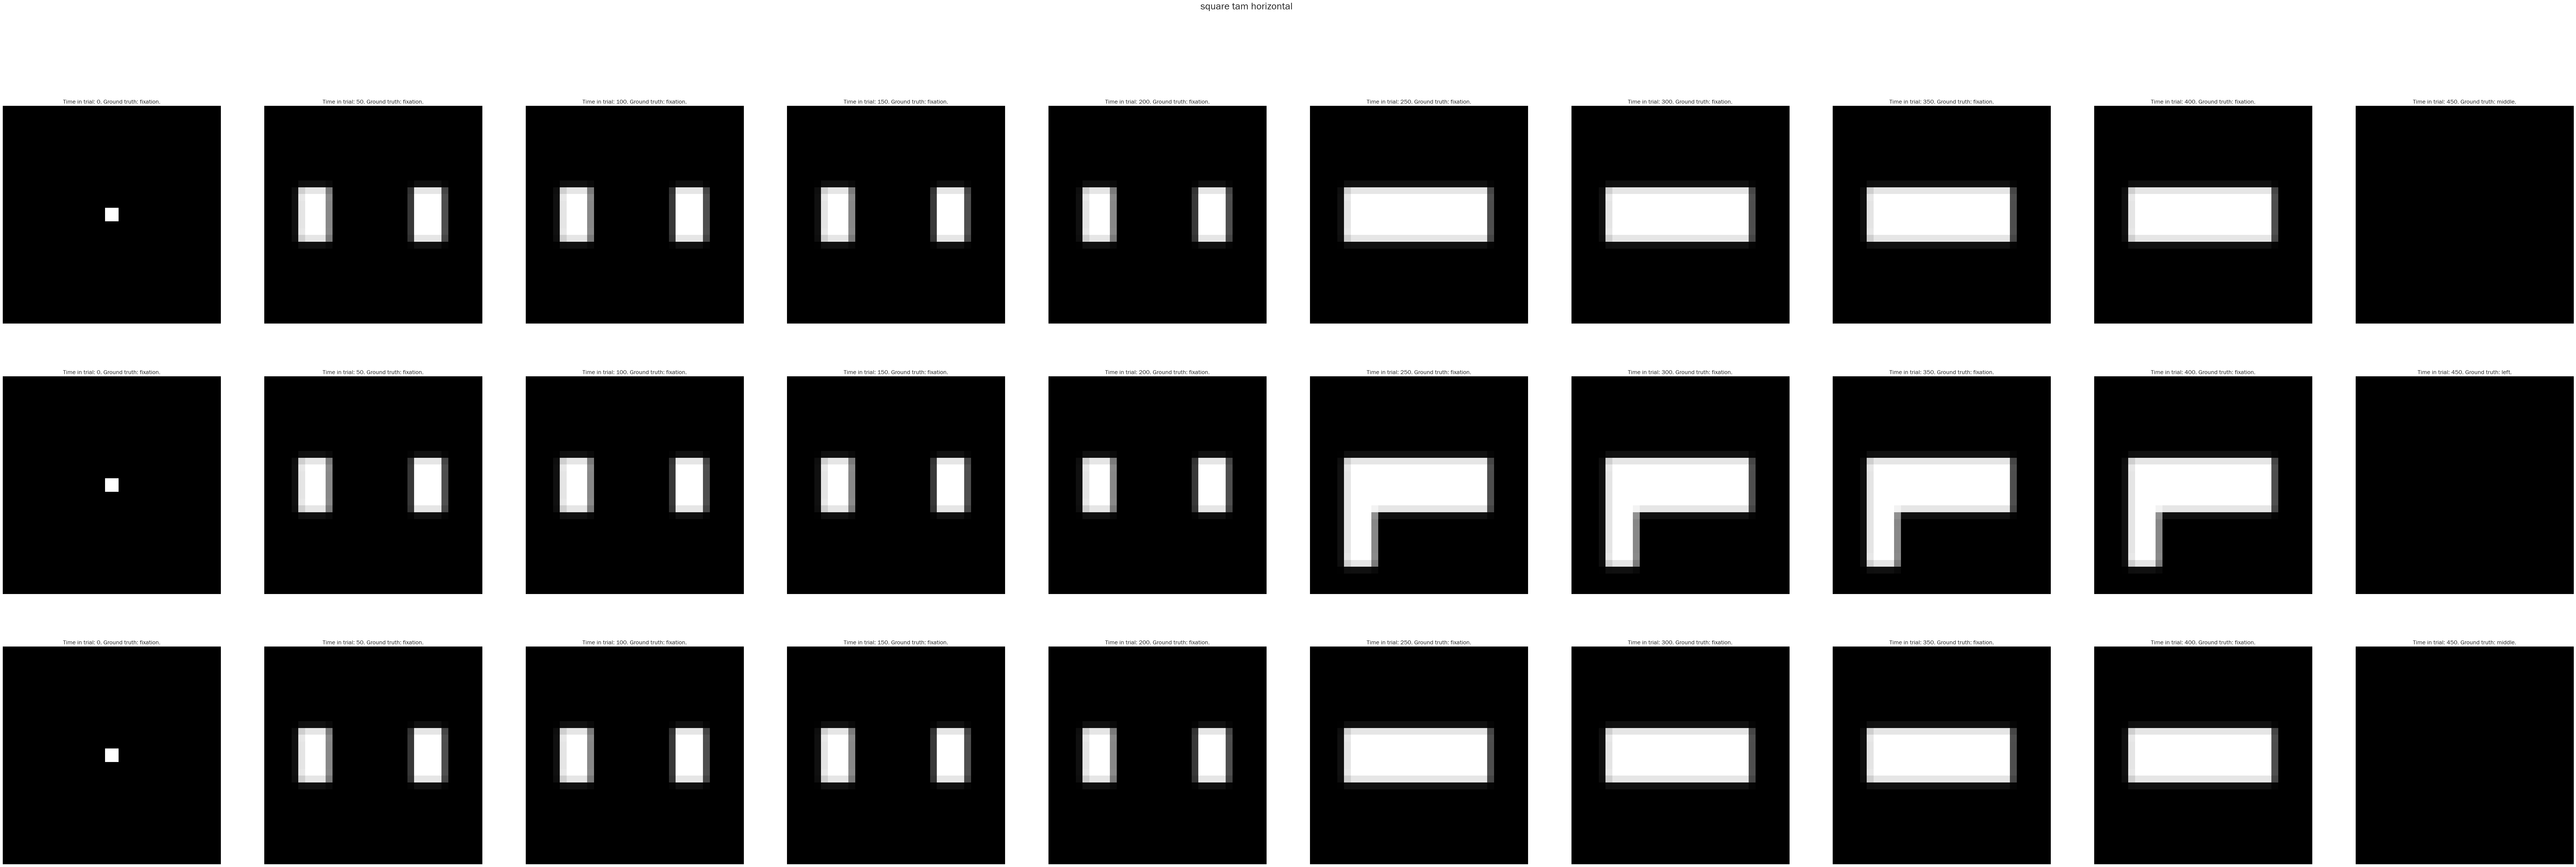

In [105]:
tam_test_datasets

## Plots

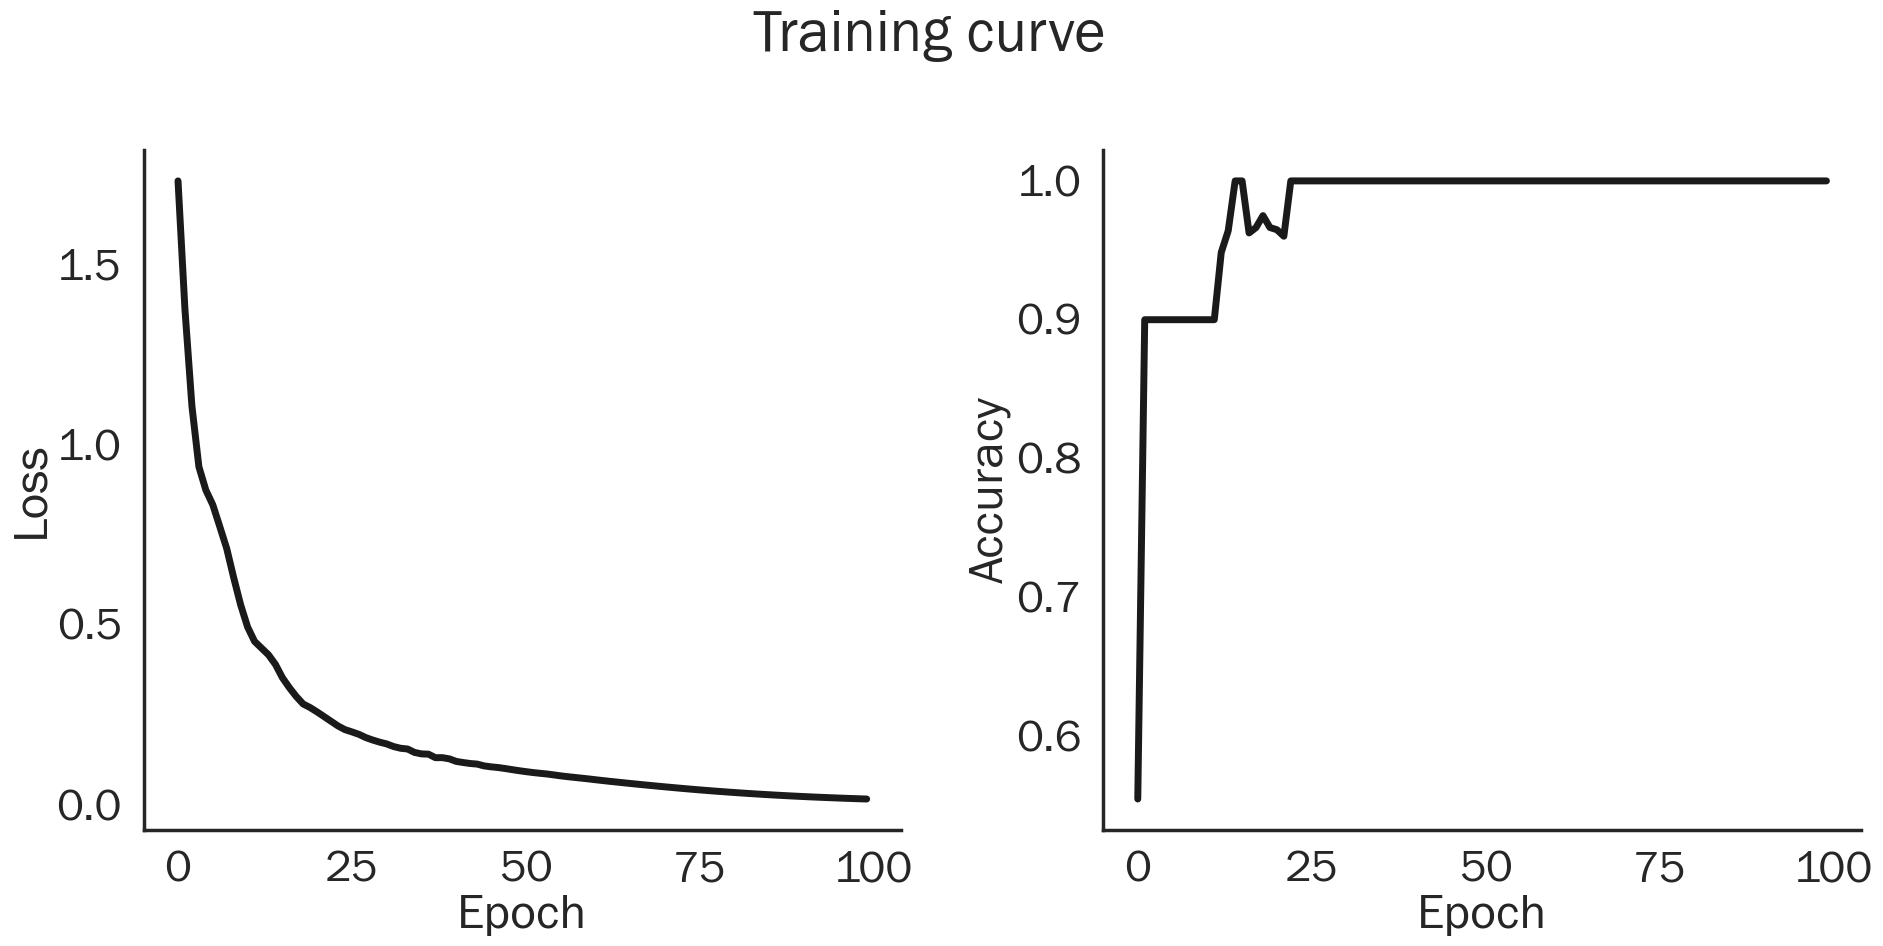

In [62]:
plot_dataset(3, training_datasets["square-horizontal"])

In [344]:
# Plot learning curve
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle("Training curve")
ax[0].plot(train_loss[:100])
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
# ax[0].set_title('Training loss')
ax[1].plot(train_acc[:100])
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
# ax[1].set_title('Training accuracy')
plt.tight_layout()
plt.savefig(FIG_DIR / 'TAM-basic_TAM-all_training_curve.png')
plt.show()

# Plot test accuracy

C:\Users\shari\AppData\Local\Temp\ipykernel_14776\3890395024.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Blues')
C:\Users\shari\AppData\Local\Temp\ipykernel_14776\3890395024.py:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["\n \n \n"] * len(accuracy_labels.keys()))


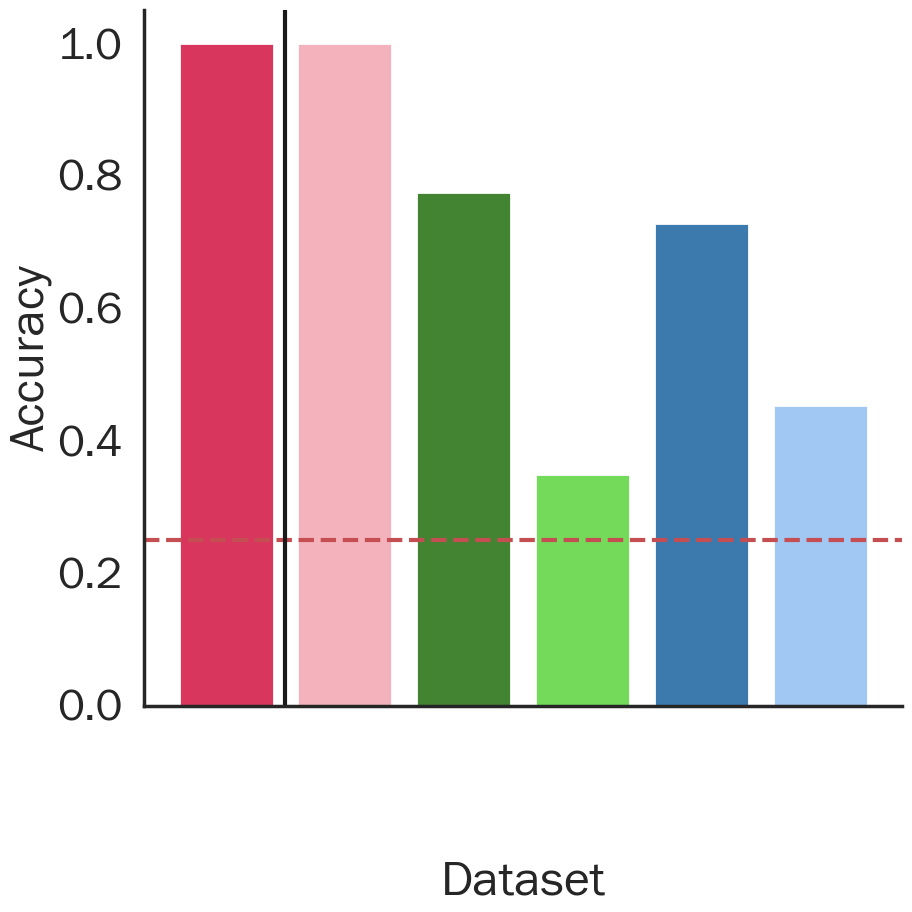

In [49]:
test_accuracies

In [410]:
accuracy_labels = {
    "Square": test_accuracies["square-tam-horizontal"],
    "Square Outline": test_accuracies["square-outline-horizontal"],
    "Triangle": test_accuracies["triangle-tam-horizontal"],
    "Triangle Outline": test_accuracies["triangle-outline-horizontal"],
    "Circle": test_accuracies["circle-tam-horizontal"],
    "Circle Outline": test_accuracies["circle-outline-horizontal"],
}

(500, 10, 128)

In [348]:
# Plot test accuracy
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
fig.suptitle("Test accuracy")

n_values = len(list(accuracy_labels.values()))

# Create a colormap
cmap = cm.get_cmap('Blues')

# Compute the color for each bar
colors = [cmap((i+1)/(n_values+1) * 0.8 + 0.2) for i in range(n_values)]
#

# Define colors
colors_high_sat = sns.husl_palette(3, s=0.8, l=0.2)  # 3 colors with high saturation
colors_low_sat = sns.husl_palette(3, s=0.8, l=0.5)  # 3 colors with low saturation

# Create a new list by interweaving the two color lists
colormap = [val for pair in zip(colors_high_sat, colors_low_sat) for val in pair]


ax.bar(accuracy_labels.keys(), accuracy_labels.values(), color=colormap)
plt.setp(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
ax.set_xlabel('Dataset')
# ax.set_xticklabels
ax.set_ylabel('Accuracy')
ax.axhline(y=0.25, color='r', linestyle='--')
ax.axvline(x=0.5, color='k', linestyle='-')
# ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'TAM-basic_TAM-all_test_accuracy.png')

Shape of the original activity: (Number of trials, ) (500,)
Shape of each trial's activity: (Trial time points, Neurons) (10, 128)
Shape of the concatenated activity: (Time points, Neurons):  (5000, 128)
Shape of the projected activity: (Time points, PCs):  (5000, 2)
Number of trials:  500
Number of time points:  10
Number of neurons:  128


# PCA on hidden layer

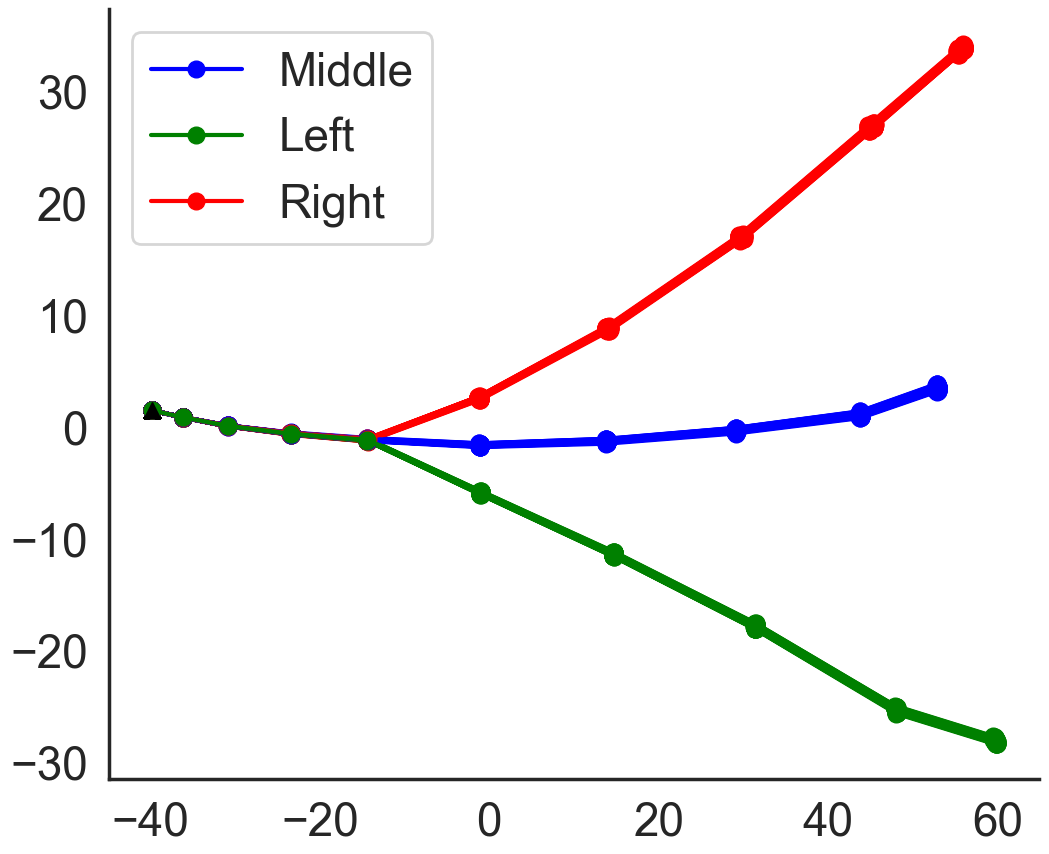

In [349]:
activity = test_activities["square-tam-horizontal"]
all_activity = np.concatenate(list(activity), axis=0)


In [350]:
# Define PCA to extract 2 components
pca = PCA(n_components=2)
activity = test_activities["square-tam-horizontal"]

# Concatenate activity for PCA
all_activity = np.concatenate(list(activity), axis=0)
print("Shape of the original activity: (Number of trials, )", activity.shape)
print("Shape of each trial's activity: (Trial time points, Neurons)", activity[0].shape)
print('Shape of the concatenated activity: (Time points, Neurons): ', all_activity.shape)

# Run PCA on the concatenated data data
pca.fit(all_activity)  # activity (Time points, Neurons)

# Find the transform to low-dimension
activity_pc = pca.transform(all_activity)
print('Shape of the projected activity: (Time points, PCs): ', activity_pc.shape)

# Save important variables
n_trials = activity.shape[0]
n_timepoints = activity[0].shape[0]
n_all_neurons = activity[0].shape[1]

print('Number of trials: ', n_trials)
print('Number of time points: ', n_timepoints)
print('Number of neurons: ', n_all_neurons)

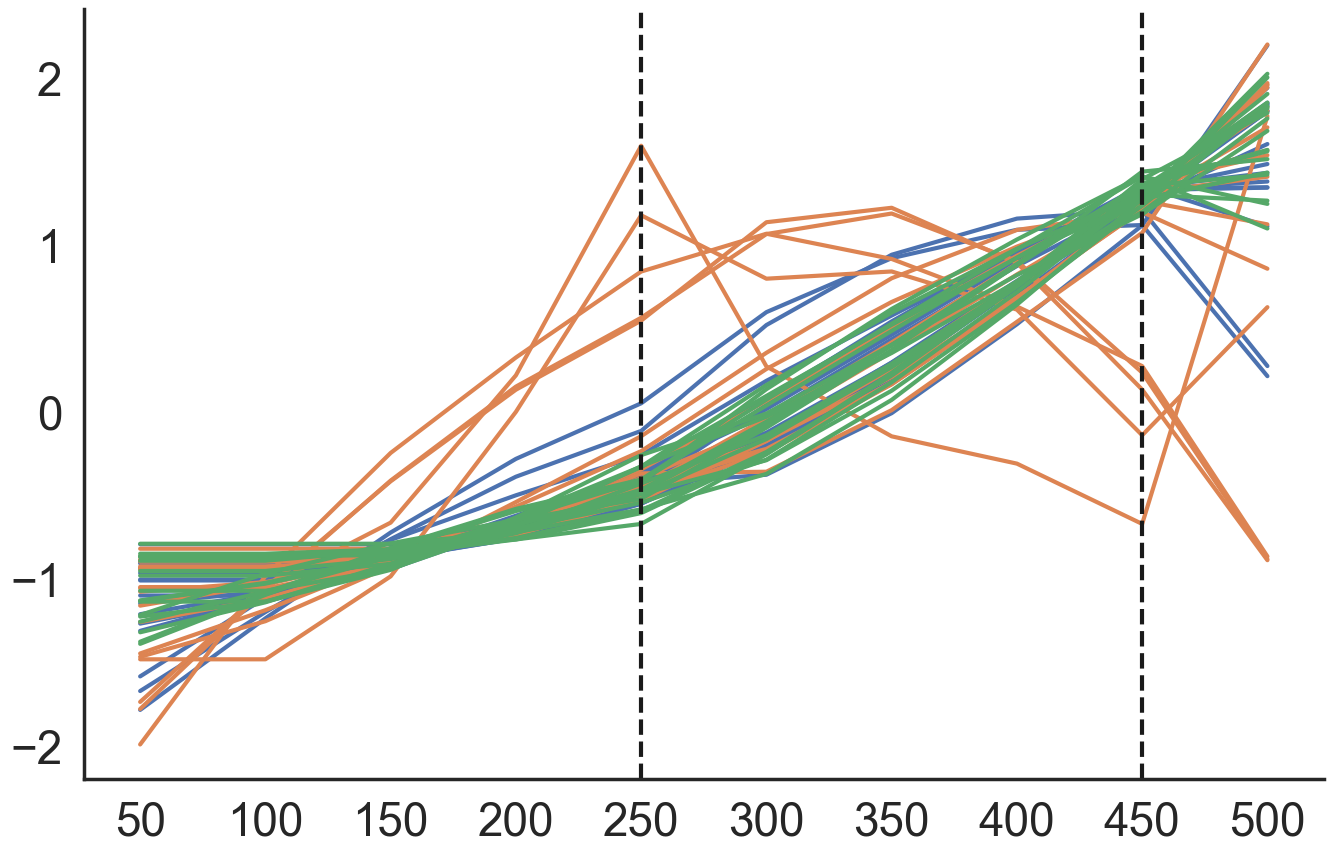

In [368]:
fig, ax = plt.subplots(figsize=(12, 10))
trial_infos = infos["square-tam-horizontal"]

# Create empty lists to hold legend handles and labels
handles = []
labels = []

# Go through trials
for t in range(n_trials):

    # Transform each trial
    activity_pc = pca.transform(activity[t])  # (Time points, PCs)

    # Select this trial's ground truth
    trial = trial_infos[t]
    if trial['ground_truth'] == 1:
        motion = 'Right'
        color = 'red'
    elif trial['ground_truth'] == 2:
        motion = 'Middle'
        color = 'blue'
    elif trial["ground_truth"] == 3:
        motion = 'Left'
        color='green'

    # Plot the PC activity
    p, = ax.plot(activity_pc[:, 0], activity_pc[:, 1], 'o-', color=color)

    # If this is the first time this type of motion is plotted, add it to the legend
    if motion not in labels:
        handles.append(p)
        labels.append(motion)

    # Plot the beginning of a trial with a special symbol
    _ = ax.plot(activity_pc[0, 0], activity_pc[0, 1], '^', color='black')

# Add a legend using the handles and labels lists
plt.legend(handles, labels)

# Change names
ax.set_title(f'PCA')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')

plt.savefig(FIG_DIR / 'TAM-basic_TAM-all_pca.png')

# PCA on individual bins

In [356]:
# Binning time points
n_bins = 3
bin_size = n_timepoints // n_bins
bins = np.histogram(np.arange(n_timepoints), n_bins)
bin_edges = np.floor(bins[1]).astype(int)

# Define PCA with 2 components
n_comps = 2
pca = PCA(n_components=n_comps)

# Initiate variables to keep track of top PCA neurons
n_top = 10  # number of top neurons with the highest weights in PCA
top_neurons = np.zeros((n_comps, n_top, n_bins))

# Loop through time bins
for i, tb in enumerate(bin_edges[:-1]):

    # Select activity across all trials and neurons for only this time bin
    bin_activity = np.concatenate([ac[tb: tb + bin_size] for ac in activity], axis=0)

    # Run PCA
    pca.fit(bin_activity)

    # Extract loadings
    loadings = pca.components_

    # Get index of top k neurons
    for pc in range(n_comps):
        neurons = np.argpartition(loadings[pc], -n_top)[-n_top:]
        top_neurons[pc, :, i] = neurons

In [357]:
# Gather the data from neurons of interest in a dataframe for easier plotting
data = {"NEURON":[], "TRIAL": [], "TIMEPOINT": [], "ACTIVITY": [], "TRIAL_TYPE": []}

# Find the highest activity neurons (without duplicates)
neurons = np.unique(top_neurons.flatten()).astype(int)

# Get the timeseries of activities
for n, neuron in enumerate(neurons):

    # Find the timeseries of activity of this neuron in all trials
    for trial in range(n_trials):
        for tp in range(n_timepoints):

            ac = activity[trial][tp, neuron]

            # Save to data
            data["NEURON"].append(neuron)
            data["TRIAL"].append(trial + 1)
            data["TIMEPOINT"].append(tp + 1)
            data["ACTIVITY"].append(ac)

            if trial_infos[trial]["ground_truth"] == 1:
                tt = "Right"
            elif trial_infos[trial]["ground_truth"] == 2:
                tt = "Mid"
            else:
                tt = "Left"
            data["TRIAL_TYPE"].append(tt)

# Turn into dataframe
df = pd.DataFrame(data)
df.head()

,NEURON,TRIAL,TIMEPOINT,ACTIVITY,TRIAL_TYPE
0,0,1,1,0.425480,Mid
1,0,1,2,1.798133,Mid
2,0,1,3,2.851161,Mid
3,0,1,4,3.738368,Mid
4,0,1,5,4.505837,Mid


In [358]:
neurons.shape

(51,)

In [361]:
# Visualizing the activity of highest-loading neurons
fig, axes = plt.subplots(1, 1, figsize=(14, 10))
custom_pal = sns.color_palette("Paired", len(df.NEURON.unique()))
fig.suptitle("Timeseries of 52 top PC Neurons")

# Change title
# ax.set_title(f"Timeseries of top PC Neurons")

# Normalize activity
plt_df = df.copy()
for neuron in neurons:
    plt_df.loc[df.NEURON == neuron, "ACTIVITY"] = zscore(plt_df.loc[df.NEURON == neuron, "ACTIVITY"])

# Palette
custom_pal = sns.dark_palette("gray", n_colors=len(neurons))
# # Plot the actual activity
# _plot = sns.lineplot(
#     data=df,
#     x="TIMEPOINT",
#     y="ACTIVITY",
#     hue="NEURON",
#     palette=custom_pal,
#     ax=axes[0]
# )
# axes[0].set_ylabel("Firing rate")
# _plot.legend_.remove()


# Plot the normalized activity
_plot = sns.lineplot(
    data=plt_df,
    x="TIMEPOINT",
    y="ACTIVITY",
    hue="NEURON",
    palette=custom_pal,
    ax=axes
)
axes.set_ylabel("Normalized Activity")
_plot.legend_.remove()

# Change properties
# for i in range(2):
axes.set_xlabel("Time")
x_ticks = np.arange(0, 550, 100)
axes.set_xticklabels(x_ticks)
axes.axvline(x=5, color='r', ls='--')
axes.axvline(x=9, color='b', ls='--')

plt.savefig(FIG_DIR / 'TAM-basic_TAM-all_pca_timeseries.png')

# RSA

In [54]:
def reshape_activity_for_rsa(activity, condition):
    # Select activity for this condition
    cond_activity = activity[condition]

    # Average across trials
    cond_activity = np.mean(cond_activity, axis=0)

    # Stack across timepoints
    cond_activity = cond_activity.reshape(-1)

    return cond_activity

In [55]:
# Construct a time point by neuron matrix (T, N) but only for times after 300ms (6th time point)
conditions = df.TRIAL_TYPE.unique()
n_conditions = len(conditions)
n_neurons = len(neurons)
n_trials = 100
cutoff = 5
slc_activity = np.zeros((n_conditions, n_trials, (n_timepoints - cutoff), n_neurons))

for trial in range(n_trials):
    for n, neuron in enumerate(neurons):
        ac = activity[trial][cutoff:, neuron]
        ac = zscore(ac, axis=0, ddof=1)
        slc_activity[int(trial_infos[trial]["ground_truth"]) - 1, trial, :, n] = ac

# Compute correlation vectors to get (N, N) matrices for each condition
rdm = np.zeros((n_conditions, n_conditions))

for cond_one in range(n_conditions):

        # Select activity for this condition
        cond_one_activity = reshape_activity_for_rsa(slc_activity, cond_one)

        # second conditino
        for cond_two in range(n_conditions):

            # Select activity for this condition
            cond_two_activity = reshape_activity_for_rsa(slc_activity, cond_two)

            # Compute correlation matrix
            rdm[cond_one, cond_two] = 1 - np.corrcoef(cond_one_activity, cond_two_activity)[0, 1]

In [370]:
# Plot the neural RDMS
fig, ax = plt.subplots(figsize=(12, 12))
condition_names = ["Right", "Mid", "Left"]

# plot
_plot = sns.heatmap(
    data=rdm,
    linewidths=.1,
    linecolor='black',
    square=True,
    # cmap="YlGnBu",
    ax=ax,
    xticklabels=condition_names,
    yticklabels=condition_names
)

ax.set_title("Motion RDM of highest activity neurons")
ax.set_xlabel("Motion direction")
ax.set_ylabel("Motion direction")
plt.savefig(FIG_DIR / 'TAM-basic_TAM-all_pca_rdm.png')

# Agglomerative clustering

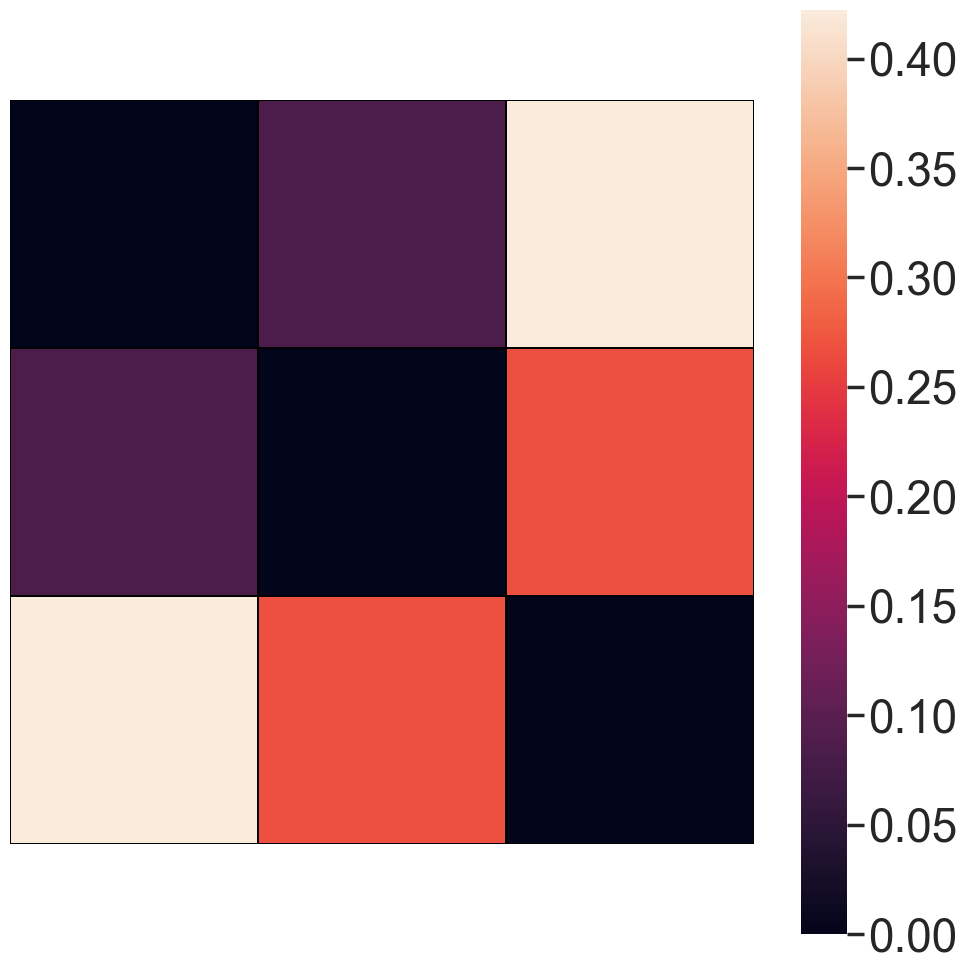

In [374]:
neurons = np.unique(top_neurons.flatten()).astype(int)
data = np.zeros((len(neurons), n_trials * n_timepoints))
all_ac = np.stack(activity)

# Get the timeseries of activities
for n, neuron in enumerate(neurons):

    # Find the timeseries of activity of this neuron in all trials
    for trial in range(n_trials):
        for tp in range(n_timepoints):

            data[n, trial + tp] = all_ac[trial, tp, neuron]

In [58]:
from scipy.cluster import hierarchy
from sklearn.preprocessing import StandardScaler


In [375]:
# Assuming your data is in an array called "data"
data = np.stack(activity)

# # Reshape your data such that each neuron's activity is a single vector
X = data.reshape(-1, data.shape[-1])

# Perform Agglomerative Clustering
clustering = AgglomerativeClustering(distance_threshold=0, n_clusters=None).fit(X.T)

# Create linkage matrix for dendrogram
counts = np.zeros(clustering.children_.shape[0])
n_samples = len(clustering.labels_)
for i, merge in enumerate(clustering.children_):
    current_count = 0
    for child_idx in merge:
        if child_idx < n_samples:
            current_count += 1  # leaf node
        else:
            current_count += counts[child_idx - n_samples]
    counts[i] = current_count

linkage_matrix = np.column_stack([clustering.children_, clustering.distances_, counts]).astype(float)

# Plot the dendrogram
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle('Hierarchical Clustering Dendrogram')

# Create a dendrogram using the linkage matrix
dendrogram = hierarchy.dendrogram(linkage_matrix, ax=ax, truncate_mode='level', p=3)

# Determine the cut-off distance that will result in a specific number of clusters
num_clusters = 3  # the number of clusters you want
cut_off_distance = clustering.distances_[-(num_clusters-1)]

# Draw a horizontal line to cut dendrogram
ax.axhline(y=cut_off_distance, color='r', linestyle='--')
# Remove x ticks
ax.set_xticks([])
ax.set_xlabel('Units')
ax.set_ylabel('Distance')

# Remove spines
# for spine in ax.spines.values():
#     spine.set_visible(False)
# remove y spine
ax.spines["left"].set_visible(False)

# Remove y axis
ax.yaxis.set_visible(False)
plt.show()

fig.savefig(FIG_DIR / 'TAM-basic_TAM-all_pca_dendrogram.png')

In [376]:
# Assuming your data is in an array called "data"
data = np.stack(activity)

# # Reshape your data such that each neuron's activity is a single vector
X = data.reshape(-1, data.shape[-1])
# Initialize a StandardScaler
scaler = StandardScaler()

# Scale the data
data_scaled = scaler.fit_transform(X.T)

# Perform Agglomerative Clustering
clustering = AgglomerativeClustering(distance_threshold=0, n_clusters=None).fit(data_scaled)

# Create linkage matrix for dendrogram
counts = np.zeros(clustering.children_.shape[0])
n_samples = len(clustering.labels_)
for i, merge in enumerate(clustering.children_):
    current_count = 0
    for child_idx in merge:
        if child_idx < n_samples:
            current_count += 1  # leaf node
        else:
            current_count += counts[child_idx - n_samples]
    counts[i] = current_count

linkage_matrix = np.column_stack([clustering.children_, clustering.distances_, counts]).astype(float)

# Plot the dendrogram
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle('Clusters of units based on activity')

# Create a dendrogram using the linkage matrix
dendrogram = hierarchy.dendrogram(linkage_matrix, ax=ax, truncate_mode='level', p=4)

# Determine the cut-off distance that will result in a specific number of clusters
num_clusters = 4  # the number of clusters you want
cut_off_distance = clustering.distances_[-(num_clusters-1)]

# Draw a horizontal line to cut dendrogram
ax.axhline(y=cut_off_distance, color='r', linestyle='--')
# Remove x ticks
ax.set_xticks([])
ax.set_xlabel('Units')
ax.set_ylabel('Distance')

# Remove spines
# for spine in ax.spines.values():
#     spine.set_visible(False)
# remove y spine
ax.spines["left"].set_visible(False)

# Remove y axis
ax.yaxis.set_visible(False)
plt.show()

fig.savefig(FIG_DIR / 'TAM-basic_TAM-all_pca_dendrogram.png')

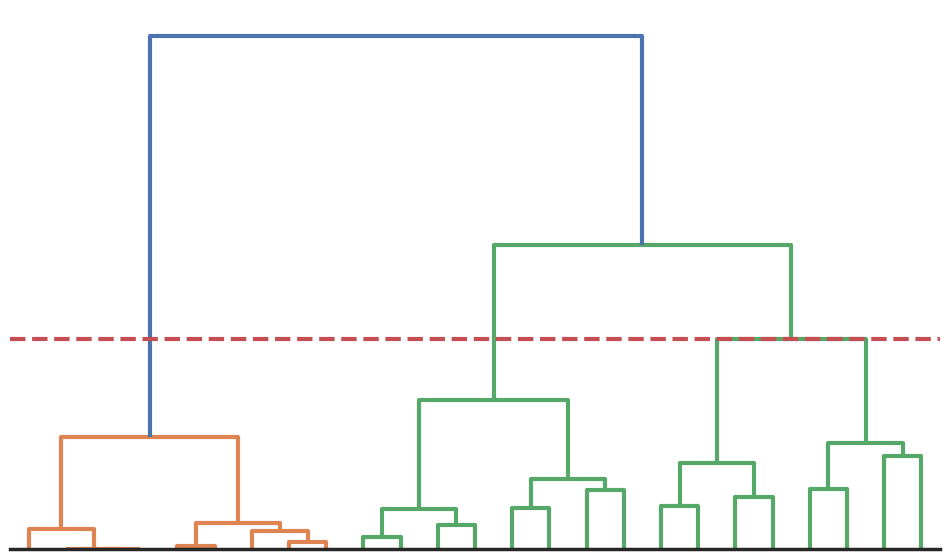

In [425]:
np.unique(top_neurons.flatten())

In [405]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Initialize a StandardScaler
scaler = StandardScaler()
data = np.stack(activity)
# Reshape data to (n_neurons, n_trials*n_timepoints)
data_reshaped = data.transpose(2, 0, 1).reshape(256, -1)
unique_neurons = np.unique(top_neurons.flatten()).astype(int)
data_reshaped = data_reshaped[unique_neurons, :]
# Scale the data
data_scaled = scaler.fit_transform(data_reshaped)

# Perform Agglomerative Clustering
cluster = AgglomerativeClustering(n_clusters=3, affinity='euclidean', linkage='ward')
cluster.fit_predict(data_scaled)

# Get the unique labels (clusters)
unique_labels = np.unique(cluster.labels_)

# Create a dictionary to store the neuron indices for each cluster
cluster_dict = {}

# Iterate over unique labels
for label in unique_labels:
    # Get the indices of neurons belonging to this cluster
    neuron_indices = np.where(cluster.labels_ == label)[0]
    # Store the indices in the dictionary
    cluster_dict[label] = neuron_indices

# Initialize a figure with multiple subplots

# Iterate over the clusters
for idx, (cluster, neuron_indices) in enumerate(cluster_dict.items()):
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))

    # Get the corresponding data for the neurons in this cluster
    cluster_data = data[:, :, neuron_indices]

    # Compute the average timecourse
    avg_timecourse = cluster_data.mean(axis=0).mean(axis=1)

    # Compute the standard error of the mean across trials
    sem_timecourse = cluster_data.std(axis=0).mean(axis=1) / np.sqrt(n_trials)

    # Plot the average timecourse on its own subplot
    ax.plot(avg_timecourse, color="k")

    # Plot the error bands
    ax.fill_between(range(n_timepoints), avg_timecourse - sem_timecourse, avg_timecourse + sem_timecourse, alpha=0.3)

    ax.set_title(f"Cluster {cluster + 1}")

    # Add explicit xticklabels from 0 to 500 ms
    ax.set_xticklabels(np.arange(0, 501, 100))

    # Add xlabel
    ax.set_xlabel('')
    ax.set_xticklabels([])

    # Add ylabel
    ax.set_ylabel('')
    ax.set_yticklabels([])

    # Add line at 300ms
    # ax.axvline(x=4, color='r', linestyle='--')

    # Show the plot
    plt.tight_layout()
    plt.show()

    # save
    fig.savefig(str(FIG_DIR / f'TAM-basic_TAM-all_cluster{idx+1}.png'))




(128, 1000)

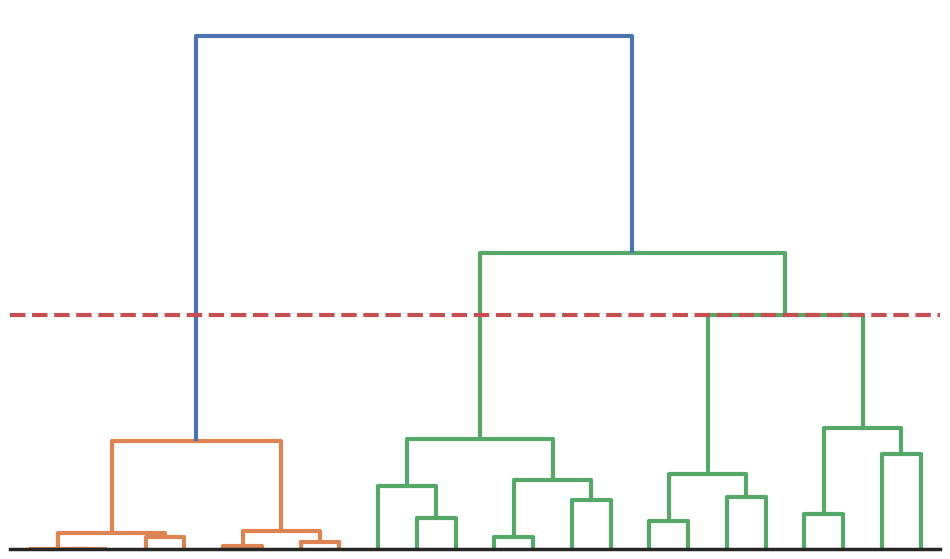

In [403]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Initialize a StandardScaler
scaler = StandardScaler()

# Define your trial conditions and corresponding colors
trial_conditions = [1, 2, 3]
colors = ['red', 'green', 'blue']
color_map = dict(zip(trial_conditions, colors))

# Reshape data to (n_neurons, n_trials*n_timepoints)
data = np.stack(activity)
data_reshaped = data.transpose(2, 0, 1).reshape(256, -1)
# data_reshaped = data_reshaped[df.NEURON.unique(), :]
# Scale the data
# data_scaled = scaler.fit_transform(data_reshaped)

# Perform Agglomerative Clustering
cluster = AgglomerativeClustering(n_clusters=4, affinity='euclidean', linkage='ward')
cluster.fit_predict(data_scaled)

# Get the unique labels (clusters)
unique_labels = np.unique(cluster.labels_)

# Create a dictionary to store the neuron indices for each cluster
cluster_dict = {}

# Iterate over unique labels
for label in unique_labels:
    # Get the indices of neurons belonging to this cluster
    neuron_indices = np.where(cluster.labels_ == label)[0]
    # Store the indices in the dictionary
    cluster_dict[label] = neuron_indices

# Initialize a figure with multiple subplots
fig, axs = plt.subplots(len(unique_labels), 1, figsize=(10, len(unique_labels)*5))

# Iterate over the clusters
for idx, (cluster, neuron_indices) in enumerate(cluster_dict.items()):
    # Get the corresponding data for the neurons in this cluster
    cluster_data = data[:, :, neuron_indices]

    # Compute the average timecourse for each condition
    for condition in trial_conditions:
        # Get the indices of trials for this condition
        condition_indices = [i for i, trial_info in enumerate(trial_infos) if trial_info["ground_truth"] == condition]

        # Get the corresponding data for these trials
        condition_data = cluster_data[condition_indices, :, :]

        # Compute the average timecourse and the standard error of the mean
        avg_timecourse = condition_data.mean(axis=2).mean(axis=0)
        # avg_timecourse = condition_data[0, :, 0]
        # sem_timecourse = condition_data.std(axis=0).mean(axis=1) / np.sqrt(len(condition_indices))

        # Plot the average timecourse and error bands with the corresponding color
        axs[idx].plot(avg_timecourse, color=color_map[condition])
        # axs[idx].fill_between(range(n_timepoints), avg_timecourse - sem_timecourse, avg_timecourse + sem_timecourse, color=color_map[condition], alpha=0.3)

        axs[idx].set_title(f"Cluster {cluster + 1}")

    # Add explicit xticklabels from 0 to 500 ms
    axs[idx].set_xticklabels(np.arange(0, 501, 100))

    # Add xlabel
    axs[idx].set_xlabel('Time (ms)')

    # Add ylabel
    axs[idx].set_ylabel('Average activity (a.u.)')

    # Add line at 300ms
    axs[idx].axvline(x=4, color='r', linestyle='--')

# Show the plot
plt.tight_layout()
plt.show()


In [429]:
print(df.NEURON.unique())

Cluster 0 includes neurons: [  0   2   8  12  17  22  24  25  34  36  37  47  48  52  53  54  55  57
  58  59  62  65  67  68  69  72  73  76  77  79  80  83  89  91  92  93
  96  98 101 105 106 107 109 111 114 119 121 127]
Cluster 1 includes neurons: [  3   4   6  10  11  15  18  23  30  31  33  40  45  46  56  81  82  85
  87 104 108 110 112 117 122 125]
Cluster 2 includes neurons: [  1   5   7   9  13  14  16  19  21  26  27  28  29  32  38  39  41  42
  43  44  51  60  61  63  64  66  70  74  75  84  86  90  94  95  97  99
 100 102 103 113 115 116 118 124 126]
Cluster 3 includes neurons: [ 20  35  49  50  71  78  88 120 123]


C:\Users\shari\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


In [427]:
# Visualizing the activity of highest-loading neurons based on
# fig, axes = plt.subplots(len(neurons), 1, figsize=(10, 8 * len(df.NEURON.unique())))
nus = df.NEURON.unique()
fig, axes = plt.subplots(1, 4, figsize=(60, 10))
custom_pal = sns.color_palette("Paired", 3)

# Start plotting
for n, neuron in enumerate([0, 6, 8, 9]):
    neuron = nus[neuron]
    # Select axis
    ax = axes[n]

    # Select data and normalize
    _df = df[df.NEURON == neuron]
    # _df.ACTIVITY = zscore(_df.ACTIVITY)

    # Plot
    _plot = sns.lineplot(
        data=_df,
        x="TIMEPOINT",
        y="ACTIVITY",
        hue="TRIAL_TYPE",
        # palette='tab10',
        ax=ax
    )

    # Vertical line at the 6th timepoint
    ax.axvline(x=5, color='b', ls='--')

    # Change properties
    ax.set_xlabel("Time (ms)")
    x_ticks = np.arange(0, 550, 100)
    ax.set_xticklabels(x_ticks)

    ax.set_ylabel("Firing Rate")

    # Remove legend
    # ax.get_legend().remove()
# save_dir = ROOT / "figures" / f"timecourse_top_{neurons.shape[0]}_neurons_v{model_version}_{stim_type}.png"
# fig.savefig(str(save_dir))

Accuracy on square-tam-horizontal = 1.0
Accuracy on square-outline-horizontal = 1.0
Accuracy on circle-tam-horizontal = 0.734
Accuracy on circle-outline-horizontal = 0.728
Accuracy on triangle-tam-horizontal = 0.896
Accuracy on triangle-outline-horizontal = 0.556


In [428]:
# Visualizing the activity of highest-loading neurons based on
# fig, axes = plt.subplots(len(neurons), 1, figsize=(10, 8 * len(df.NEURON.unique())))
nus = df.NEURON.unique()
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
custom_pal = sns.color_palette("Paired", 3)

# Start plotting
for n, neuron in enumerate([0, 6]):
    neuron = nus[neuron]
    # Select axis
    ax = axes[n]

    # Select data and normalize
    _df = df[df.NEURON == neuron]
    # _df.ACTIVITY = zscore(_df.ACTIVITY)

    # Plot
    _plot = sns.lineplot(
        data=_df,
        x="TIMEPOINT",
        y="ACTIVITY",
        hue="TRIAL_TYPE",
        palette='husl',
        ax=ax
    )

    # Vertical line at the 6th timepoint
    ax.axvline(x=5, color='b', ls='--')

    # Change properties
    ax.set_xlabel("Time (ms)")
    x_ticks = np.arange(0, 550, 100)
    ax.set_xticklabels(x_ticks)

    ax.set_ylabel("Firing Rate")

    # Remove legend
    # ax.get_legend().remove()
# save_dir = ROOT / "figures" / f"timecourse_top_by_condition_1.png"
# fig.savefig(str(save_dir))

In [436]:
# Visualizing the activity of highest-loading neurons based on
# fig, axes = plt.subplots(len(neurons), 1, figsize=(10, 8 * len(df.NEURON.unique())))
nus = df.NEURON.unique()
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
custom_pal = sns.color_palette("Paired", 3)

# Start plotting
for n, neuron in enumerate([8, 9]):
    neuron = nus[neuron]
    # Select axis
    ax = axes[n]

    # Select data and normalize
    _df = df[df.NEURON == neuron]
    # _df.ACTIVITY = zscore(_df.ACTIVITY)

    # Plot
    _plot = sns.lineplot(
        data=_df,
        x="TIMEPOINT",
        y="ACTIVITY",
        hue="TRIAL_TYPE",
        palette='husl',
        ax=ax
    )

    # Vertical line at the 6th timepoint
    ax.axvline(x=5, color='b', ls='--')

    # Change properties
    ax.set_xlabel("Time (ms)")
    x_ticks = np.arange(0, 550, 100)
    ax.set_xticklabels(x_ticks)

    ax.set_ylabel("Firing Rate")

    # Remove legend
    # ax.get_legend().remove()
# save_dir = ROOT / "figures" / f"timecourse_top_by_condition_2.png"
# fig.savefig(str(save_dir))

In [437]:
from sklearn.cluster import AgglomerativeClustering

# Reshape data to (n_trials*n_timepoints, n_neurons)
data = np.stack(activity)
# data_reshaped = data.reshape(1000, 256)
data_reshaped = data.reshape(-1, data.shape[-1])

# Perform Agglomerative Clustering
cluster = AgglomerativeClustering(n_clusters=4, affinity='euclidean', linkage='ward')
cluster.fit_predict(data_reshaped.T)  # transpose to get shape (n_neurons, n_samples)

# Get the unique labels (clusters)
unique_labels = np.unique(cluster.labels_)

# Create a dictionary to store the neuron indices for each cluster
cluster_dict = {}

# Iterate over unique labels
for label in unique_labels:
    # Get the indices of neurons belonging to this cluster
    neuron_indices = np.where(cluster.labels_ == label)[0]
    # Store the indices in the dictionary
    cluster_dict[label] = neuron_indices

# Print the dictionary
for cluster, neuron_indices in cluster_dict.items():
    print(f"Cluster {cluster} includes neurons: {neuron_indices}")

,Cluster,Dataset,Accuracy
0,1,square-tam-horizontal,1.00
1,1,square-outline-horizontal,1.00
2,1,circle-tam-horizontal,0.75
3,1,circle-outline-horizontal,0.77
4,1,triangle-tam-horizontal,0.75


# Lesion analysis

In [380]:
# Create network to train on the normal stimuli
net = TAMNet(
    dataset=training_datasets["square-horizontal"],
    hidden_size=256,
    output_size=training_datasets["square-horizontal"].env.action_space.n,
    learning_rate=0.001,
    device=device
)

# Load the trained weights
model = net.RNN
model.load_state_dict(torch.load(MODEL_DIR / 'learned_horiz_TAM-basic_256_VSS_only_last.pt'))
model.eval()

# Test on datasets
acc = defaultdict()
act = defaultdict()
infos = defaultdict()

for et, dataset in tam_test_datasets.items():
    info, activity, test_acc = net.test_rnn(100, dataset)
    infos[et] = info
    acc[et] = test_acc
    act[et] = activity
    print(f'Accuracy on {et} = {test_acc}')

Cluster 0 includes neurons: [  0   2   8  12  22  24  25  34  36  37  47  48  52  54  55  57  58  59
  62  65  67  68  69  72  73  76  77  79  80  83  89  91  92  93  96  98
 101 106 107 109 111 114 119 121]
Cluster 1 includes neurons: [  3   4   6  10  11  15  17  18  23  30  31  33  40  45  46  53  56  81
  82  85  87 104 105 108 110 112 117 122 125 127]
Cluster 2 includes neurons: [ 20  35  49  50  71  78  88 120 123]
Cluster 3 includes neurons: [  1   5   7   9  13  14  16  19  21  26  27  28  29  32  38  39  41  42
  43  44  51  60  61  63  64  66  70  74  75  84  86  90  94  95  97  99
 100 102 103 113 115 116 118 124 126]


C:\Users\shari\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


In [77]:
df = pd.DataFrame(columns=["Cluster", "Dataset", "Accuracy"])
cluster_data = []
dataset_data = []
acc_data = []

for cluster in range(4):
    net = TAMNet(
        dataset=training_datasets["square-horizontal"],
        hidden_size=256,
        output_size=training_datasets["square-horizontal"].env.action_space.n,
        learning_rate=0.001,
        device=device
    )

    # Load the trained weights
    model = net.RNN
    model.load_state_dict(torch.load(MODEL_DIR / 'learned_horiz_TAM-basic_256_VSS.pt'))
    model.eval()

    for neuron in cluster_dict[cluster]:
        model.rnn.h2h.weight.data[:, neuron] = 0
        model.fc.weight.data[:, neuron] = 0

    # Test on datasets
    for et, dataset in tam_test_datasets.items():
        info, activity, test_acc = net.test_rnn(100, dataset)

        cluster_data.append(cluster + 1)
        dataset_data.append(et)
        acc_data.append(test_acc)

df["Cluster"] = cluster_data
df["Dataset"] = dataset_data
df["Accuracy"] = acc_data

In [818]:
print(df.head())

   Cluster                    Dataset  Accuracy
0        0      square-tam-horizontal      0.70
1        0  square-outline-horizontal      0.68
2        0      circle-tam-horizontal      0.61
3        0  circle-outline-horizontal      0.66
4        0    triangle-tam-horizontal      0.64


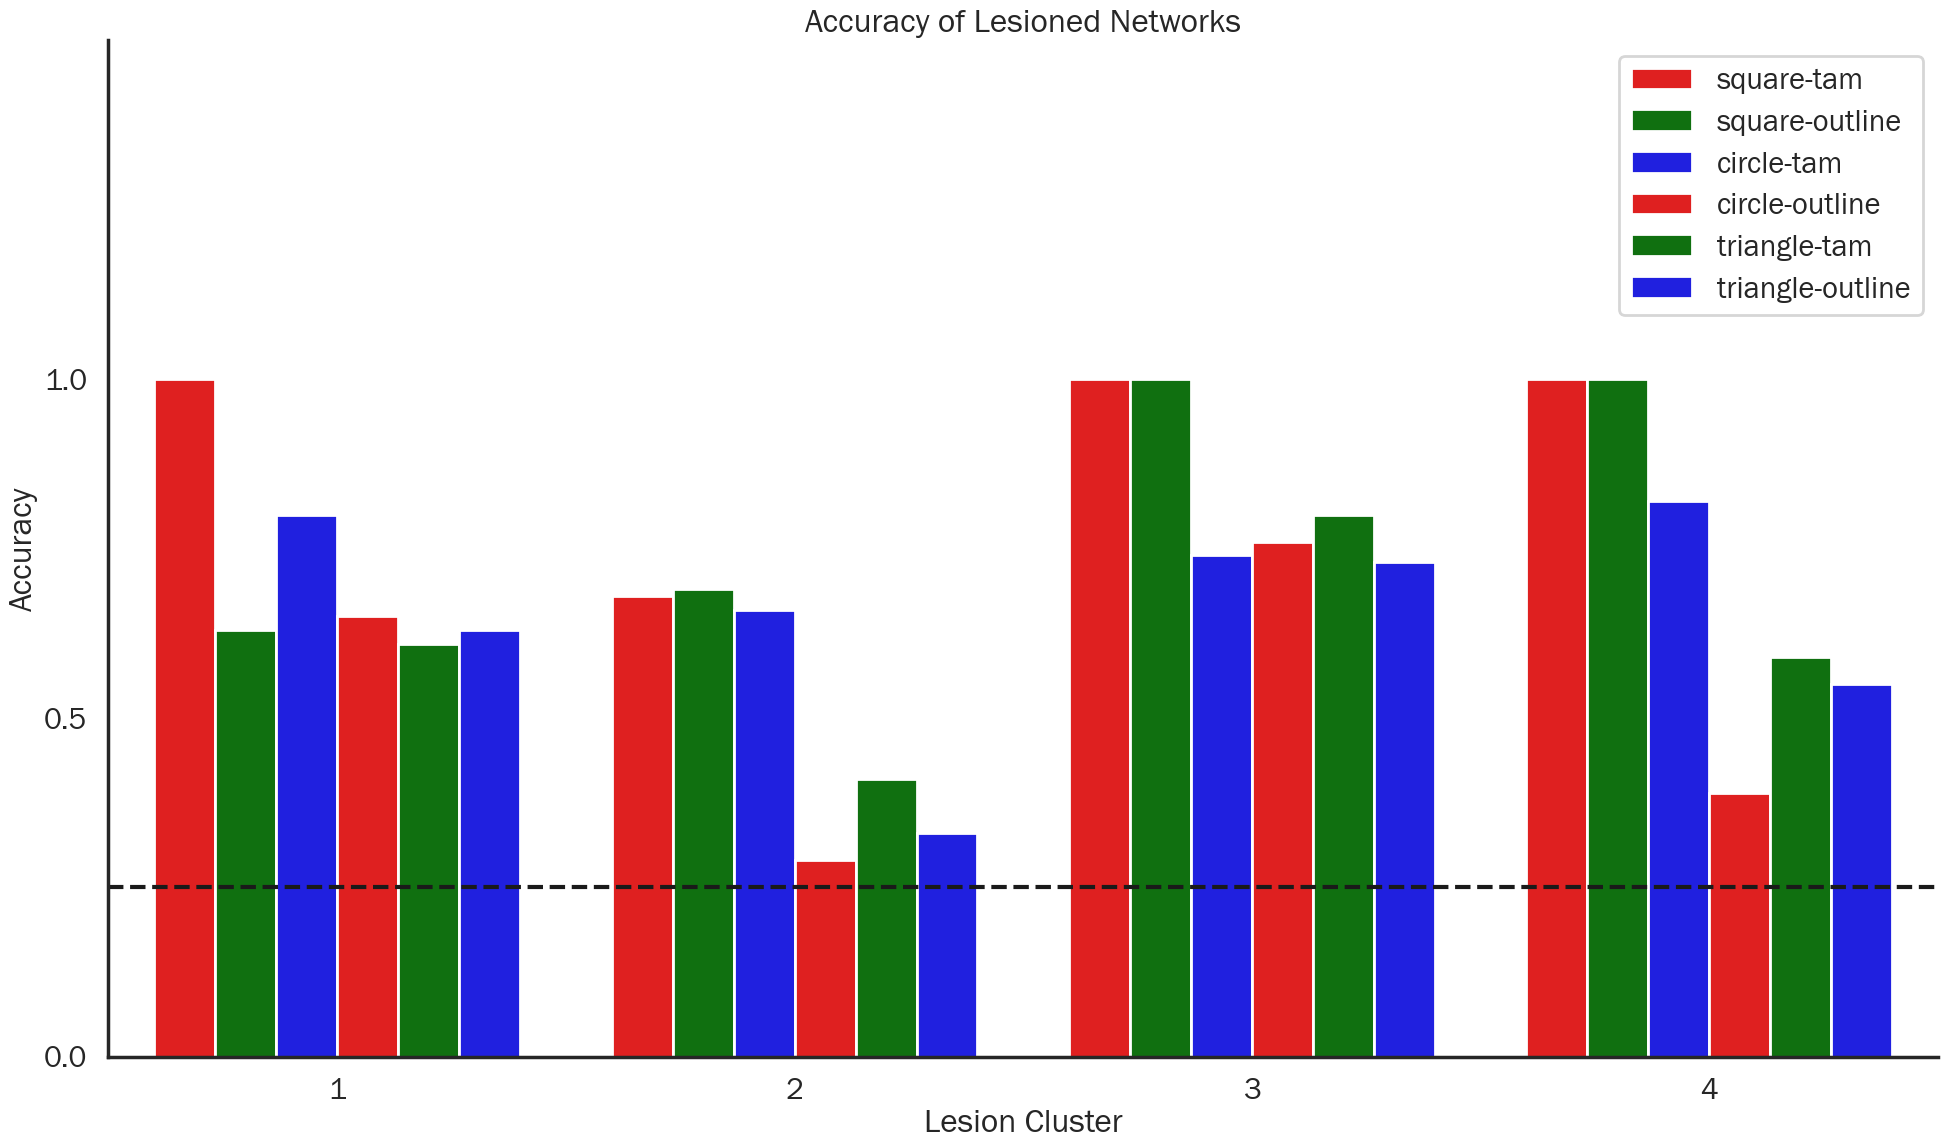

In [81]:
# plot the accuracy
fig, ax = plt.subplots(figsize=(20, 12))
sns.barplot(data=df, x="Cluster", y="Accuracy", hue="Dataset", ax=ax, palette=colors)
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_xlabel("Lesion Cluster")
ax.set_title("Accuracy of Lesioned Networks")
ax.axhline(y=0.25, color='k', ls='--')
# vertical line after first four bars
# ax.axvline(x=0.5, color='k', ls='-')
# rotate xticks
# Change legend labels to be more descriptive
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=[label[:-11] for label in labels])

# plt.setp(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.ylim(0, 1.5)
plt.yticks(np.arange(0, 1.5, 0.5))
plt.tight_layout()
plt.show()
# Save
fig.savefig(str(FIG_DIR / "lesion_analysis.png"))